   Year        T2M       RH2M  PRECTOTCORR District_Name      NDVI     Yield
0  2015  26.667507  44.516877       629.19       Lucknow  0.490388  2.368930
1  2016  26.608907  46.551257       869.86       Lucknow  0.382516  2.670001
2  2017  26.421589  48.908712       960.07       Lucknow  0.378340  2.580003
3  2018  26.099068  50.693671      1216.01       Lucknow  0.382765  2.730016
4  2019  25.414192  57.753973      1122.86       Lucknow  0.394574  2.661996

TOTAL ROWS:
80

XGBOOST PERFORMANCE
MAE  : 0.5162885775246685
RMSE : 0.6406417180530692
R2   : -0.5219409217677335


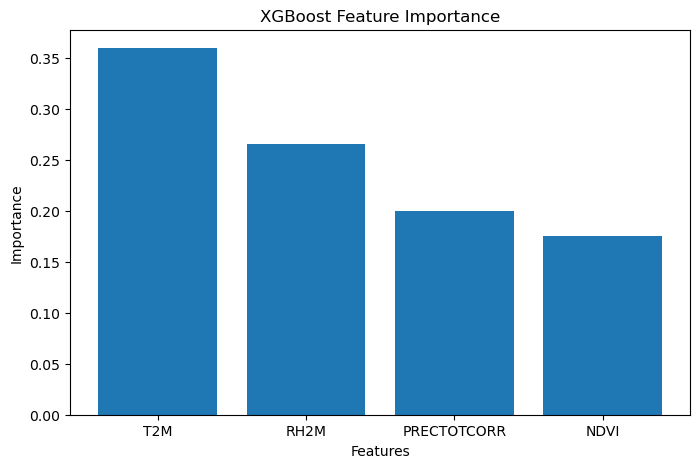

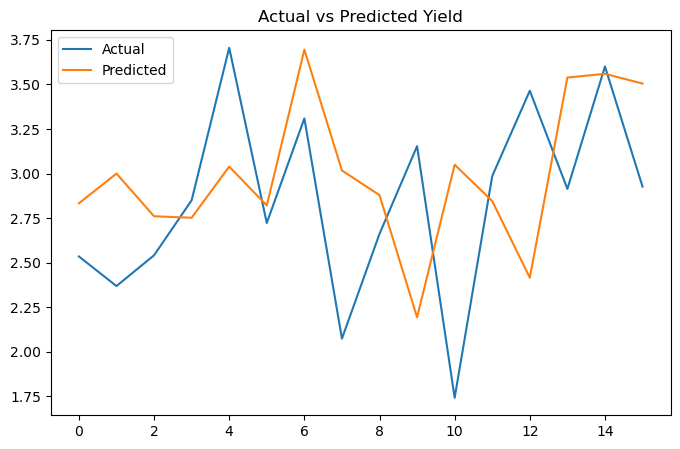

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================
# LOAD FINAL DATASET
# =====================================

df = pd.read_csv(
    "../datasets/final_district_dataset.csv"
)

print(df.head())

print("\nTOTAL ROWS:")
print(len(df))


# =====================================
# FEATURES & TARGET
# =====================================

X = df[[
    'T2M',
    'RH2M',
    'PRECTOTCORR',
    'NDVI'
]]

y = df['Yield']


# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =====================================
# XGBOOST MODEL
# =====================================

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


# =====================================
# PREDICTIONS
# =====================================

y_pred = model.predict(X_test)


# =====================================
# EVALUATION
# =====================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nXGBOOST PERFORMANCE")
print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"R2   : {r2}")


# =====================================
# FEATURE IMPORTANCE
# =====================================

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("XGBoost Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()


# =====================================
# ACTUAL VS PREDICTED
# =====================================

plt.figure(figsize=(8,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    y_pred,
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted Yield")

plt.show()